# Variational Quantum Classifier (VQC)

## Why This Notebook Exists

A lot of quantum machine learning explanations jump straight into equations and circuit diagrams without ever answering the important question:

> “What is this thing actually *doing*?”

So before we touch code, let’s build intuition.

A Variational Quantum Circuit (VQC) is basically a quantum circuit with adjustable parameters.

Think of those parameters as knobs.

The quantum computer runs the circuit using the current knob settings.

Then:
- we measure the output,
- calculate how wrong the model was,
- and use a classical optimizer to adjust the knobs.

That loop repeats over and over.

So despite the fancy name, a VQC is really just:

> a trainable function built from quantum gates.

The interesting part is that instead of neurons and matrix multiplications like in neural networks, the model learns through:
- rotations,
- interference,
- entanglement,
- and measurement probabilities.

That’s what we’re exploring here.

---

# Step 1 — Imports

We’ll use:
- `PennyLane` for quantum circuits
- `scikit-learn` for datasets
- `matplotlib` for visualization

In [1]:
import pennylane as qml
import pennylane.numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 2 — Creating a Dataset

We need something for the quantum model to learn.

We’ll use the famous **two moons** dataset.

If you’ve never seen it before, it’s basically two interlocking crescent shapes.

What makes it useful is that:
- the data is *not linearly separable*
- a straight line cannot solve the classification problem cleanly

That forces the model to learn more interesting decision boundaries.

This is exactly the kind of thing variational circuits are often tested on.

---

## Generate the Dataset

In [2]:
X, y = make_moons(
    n_samples=200,
    noise=0.1,
    random_state=42
)

# Convert labels from {0,1} to {-1,+1}
y = 2 * y - 1

# Normalize inputs
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Visualizing the Dataset

Always visualize your data.

Seriously.

One of the biggest beginner mistakes in ML is training models on datasets they never actually looked at.

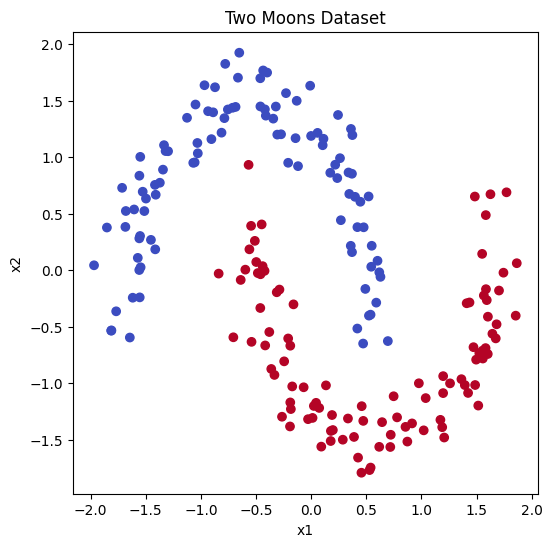

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap='coolwarm'
)

plt.title("Two Moons Dataset")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

You should see two curved clusters.

The challenge is teaching the quantum model how to separate them.

---

# Step 3 — Building a Quantum Circuit

Now we create the actual quantum model.

This part tends to intimidate people at first, but the structure is simpler than it looks.

Our circuit will do three things:

1. Encode classical data into qubits
2. Apply trainable quantum gates
3. Measure an expectation value

That measurement becomes the model’s prediction.

---

# Angle Encoding

We need some way to put classical numbers into a quantum circuit.

One of the simplest methods is **angle encoding**.

We take a feature value and use it as a rotation angle.

So instead of:
- storing data in memory,

we literally rotate qubits according to the data.

That’s very weird the first time you encounter it.

But it’s also one of the core ideas in QML.

In [4]:
n_qubits = 2
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

# The Ansatz

“Ansatz” is just physics language for:

> the structure of the trainable circuit.

This is the part that learns.

We’ll use:
- rotation gates
- followed by entangling CNOT gates

The rotations are trainable parameters.

The CNOTs allow qubits to influence each other.

In [5]:
def ansatz(weights):

    for layer in range(n_layers):

        for qubit in range(n_qubits):

            qml.RY(weights[layer, qubit], wires=qubit)

        qml.CNOT(wires=[0, 1])

# Full Quantum Model

Now we combine:
- data encoding
- trainable layers
- measurement

The output will be a number between roughly -1 and 1.

In [6]:
@qml.qnode(dev)
def circuit(x, weights):

    # Angle encoding
    for i in range(n_qubits):
        qml.RX(x[i], wires=i)

    # Trainable circuit
    ansatz(weights)

    # Measurement
    return qml.expval(qml.PauliZ(0))

# Testing the Circuit

Before training anything, let’s just see if the circuit runs.

In [7]:
weights = np.random.randn(
    n_layers,
    n_qubits,
    requires_grad=True
)

example_output = circuit(X_train[0], weights)

print("Circuit output:", example_output)

Circuit output: 0.4781826604525074


If everything worked correctly, you should get a numerical output.

That means:
- the quantum circuit executed,
- the data was encoded,
- and a measurement was returned.

Now we can train it.

---

# Step 4 — Defining the Loss Function

The model predicts values.

We compare those predictions against the true labels.

Then we calculate how wrong the model was.

That “wrongness” is the loss.

We’ll use Mean Squared Error (MSE) because it’s simple and easy to visualize.

In [8]:
def mse_loss(y_true, y_pred):

    y_pred = np.array(y_pred)

    return np.mean((y_true - y_pred) ** 2)

In [9]:
def cost(weights, X, y):

    predictions = np.array([
        circuit(x, weights)
        for x in X
    ])

    return mse_loss(y, predictions)

# Step 5 — Training the Quantum Model

This is where the learning happens.

The optimizer:
1. computes gradients,
2. updates parameters,
3. tries to reduce the loss.

PennyLane automatically uses the parameter-shift rule under the hood.

That means the gradients are coming from actual quantum evaluations, not ordinary backpropagation.

In [10]:
optimizer = qml.GradientDescentOptimizer(stepsize=0.1)

epochs = 60

loss_history = []

In [11]:
for epoch in range(epochs):

    weights = optimizer.step(
        lambda w: cost(w, X_train, y_train),
        weights
    )

    current_loss = cost(weights, X_train, y_train)

    loss_history.append(current_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss = {current_loss:.4f}")

Epoch 0 | Loss = 1.1044
Epoch 10 | Loss = 1.0251
Epoch 20 | Loss = 1.0044
Epoch 30 | Loss = 0.9997
Epoch 40 | Loss = 0.9987
Epoch 50 | Loss = 0.9984


# Visualizing Training

This plot matters a lot.

A surprising number of ML beginners train models without ever looking at the optimization curve.

The loss curve tells you:
- whether learning is happening,
- whether training is unstable,
- whether gradients vanished,
- whether learning stalled.

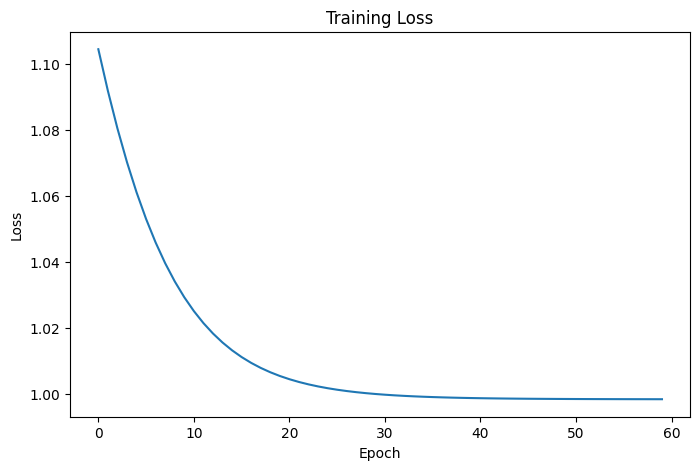

In [12]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

If the curve generally trends downward, the model is learning.

Not perfectly.

Not magically.

But learning.

---

# Step 6 — Making Predictions

Now let’s see what the model actually learned.

In [13]:
predictions = np.array([
    np.sign(circuit(x, weights))
    for x in X_test
])

accuracy = np.mean(predictions == y_test)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.5


# Decision Boundary Visualization

This is probably the most important visualization in the notebook.

It shows:
- what regions the model classifies as each class,
- how the circuit “thinks,”
- and whether the model actually learned structure.

Without this, the model feels abstract.

With it, the model becomes tangible.

In [14]:
xx, yy = np.meshgrid(
    np.linspace(-3, 3, 150),
    np.linspace(-3, 3, 150)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

In [15]:
Z = np.array([
    circuit(point, weights)
    for point in grid_points
])

Z = Z.reshape(xx.shape)

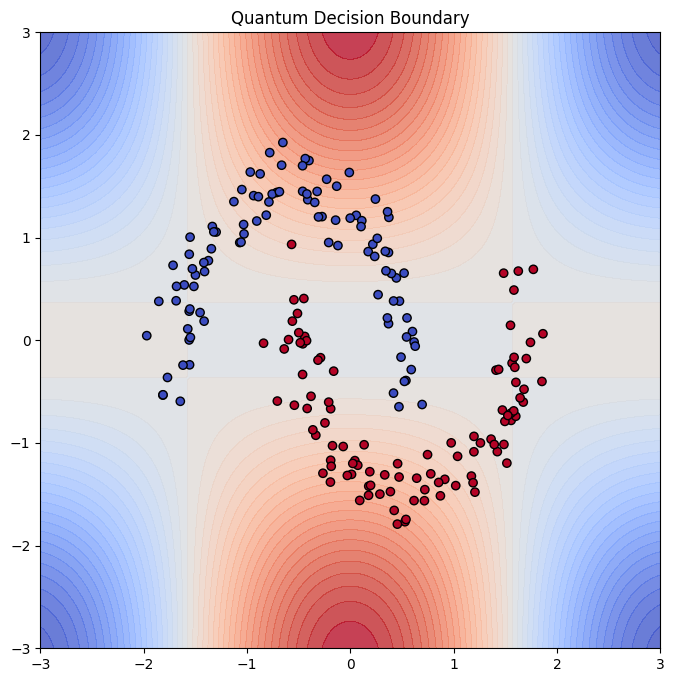

In [16]:
plt.figure(figsize=(8,8))

plt.contourf(
    xx,
    yy,
    Z,
    levels=50,
    alpha=0.8,
    cmap='coolwarm'
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors='black',
    cmap='coolwarm'
)

plt.title("Quantum Decision Boundary")

plt.show()

## Why This Visualization Matters

This is the point where things start becoming very real.

You are not just looking at a random ML graph anymore. You are literally watching a quantum circuit carve up geometric space into regions corresponding to different predictions.

Look carefully at the shapes.

The circuit is effectively learning a geometric partition of space.

Different parameter values create different transformations of the quantum state, which eventually produce different expectation values during measurement.

Those expectation values become predictions.

This is why variational quantum circuits are often compared to neural networks:

- parameters define behavior
- optimization updates those parameters
- the model learns decision boundaries from data

except here, the transformations happen in Hilbert space using unitary operations.

That is the core conceptual shift.

In [17]:
# Experiment 1 — Change Circuit Depth

depth = 3

weights = np.random.randn(depth, n_qubits, requires_grad=True)

@qml.qnode(dev)
def deeper_circuit(x, weights):

    angle_encoding(x)

    for layer in range(depth):

        for i in range(n_qubits):
            qml.RY(weights[layer][i], wires=i)

        qml.CNOT(wires=[0, 1])

    return qml.expval(qml.PauliZ(0))


def deeper_cost(weights, X, y):

    preds = np.array([deeper_circuit(x, weights) for x in X])

    return np.mean((y - preds) ** 2)


optimizer = qml.GradientDescentOptimizer(stepsize=0.1)

epochs = 60

loss_history = []

for epoch in range(epochs):

    weights = optimizer.step(
        lambda w: deeper_cost(w, X_train, y_train),
        weights
    )

    loss = deeper_cost(weights, X_train, y_train)

    loss_history.append(loss)

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training with Deeper Circuit")
plt.show()

NameError: name 'angle_encoding' is not defined

## What Happened?

By increasing depth, we increased the expressive power of the circuit.

The model now has:
- more parameters
- more rotations
- more nonlinear transformations
- more opportunities to entangle information

This often improves performance.

But there is a catch.

As circuits become deeper:
- gradients can vanish
- optimization becomes unstable
- training slows down
- noise affects results more strongly

This is one of the biggest themes in quantum machine learning research:
> more expressive circuits are not automatically better circuits.

In [ ]:
# Experiment 2 — Change Entanglement Pattern

@qml.qnode(dev)
def no_entanglement_circuit(x, weights):

    angle_encoding(x)

    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)

    return qml.expval(qml.PauliZ(0))


weights_simple = np.random.randn(n_qubits, requires_grad=True)

preds_simple = np.array([
    no_entanglement_circuit(x, weights_simple)
    for x in X
])

plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=preds_simple,
    cmap='coolwarm'
)

plt.title("Predictions Without Entanglement")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.colorbar(label="Prediction")

plt.show()

## Why Entanglement Matters

Without entanglement, each qubit behaves mostly independently.

That severely limits what the circuit can represent.

Entanglement allows:
- correlations between qubits
- richer feature interactions
- more complex decision boundaries

This is one reason people believe quantum models *might* eventually outperform classical ones on certain problems.

The keyword is *might*.

Because richer circuits are also:
- harder to train
- more sensitive to noise
- more computationally expensive
- sometimes classically simulable anyway

The entire field is still trying to figure out where genuine quantum advantage actually appears.

# Reflection

This notebook may look simple on the surface.

But conceptually, you just implemented:
- data encoding
- a parameterized quantum circuit
- hybrid optimization
- gradient-based training
- geometric classification
- decision boundary visualization

which are the foundations of modern variational quantum machine learning.

The deeper idea behind all of this is extremely important:

> A quantum computer is not magically "doing AI."

Instead:
- data gets embedded into quantum states
- circuits transform those states
- measurements extract information
- optimization tunes the transformations

The same learning principles from classical ML still exist:
- optimization
- generalization
- overfitting
- model capacity
- trainability

The difference is the computational substrate.

And that raises the central question of the field:

> Can quantum systems represent or learn patterns that classical systems fundamentally struggle with?

Right now, nobody fully knows.

That uncertainty is part of what makes QML interesting.